In [9]:
# Example 1. ARIMA

In [1]:
import pandas as pd

data = pd.read_csv("macrodata_time_series.csv", index_col=0)
data.index = pd.PeriodIndex(data.index, freq="Q")

# extract real GDP variable for analysis
y = data['realgdp']

/Users/ignasi/opt/anaconda3/lib/python3.7/site-packages/statsmodels/graphics/tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


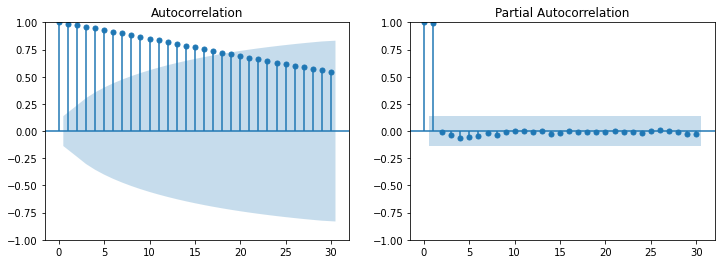

In [2]:
#ACF / PACF diagnostics
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y, ax=ax[0], lags=30)
plot_pacf(y, ax=ax[1], lags=30)
plt.show()

# this suggests ARIMA(1,0,1)
# ACF decreases steadily
# PACF shows spike at lag 1 - AR(1) candidate

In [11]:
# ARIMA on GDP
import numpy as np

# make stationary (growth rate)
y_diff = np.log(y).diff().dropna()

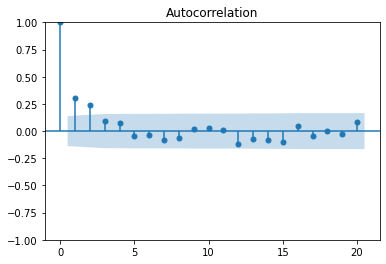

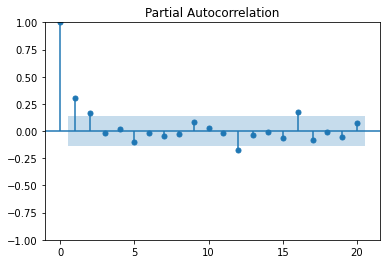

In [12]:
#ACF/PACF

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(y_diff, lags=20)
plot_pacf(y_diff, lags=20)
plt.show()

/Users/ignasi/opt/anaconda3/lib/python3.7/site-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


                               SARIMAX Results                                
Dep. Variable:                realgdp   No. Observations:                  202
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 681.708
Date:                Fri, 10 Apr 2026   AIC                          -1355.416
Time:                        10:13:58   BIC                          -1342.183
Sample:                    06-30-1959   HQIC                         -1350.062
                         - 09-30-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0078      0.001      7.446      0.000       0.006       0.010
ar.L1          0.6667      0.147      4.539      0.000       0.379       0.955
ma.L1         -0.3997      0.177     -2.255      0.0

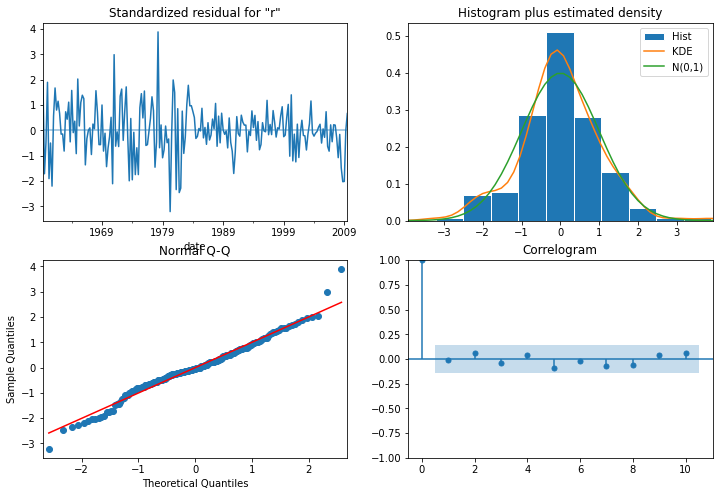

In [24]:
# FIT ARIMA
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y_diff, order=(1,0,1))
result = model.fit()

print(result.summary())

# Diagnostics
result.plot_diagnostics(figsize=(12,8))
plt.show()

                               SARIMAX Results                                
Dep. Variable:                 volume   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  41.093
Date:                Fri, 10 Apr 2026   AIC                            -76.186
Time:                        10:13:43   BIC                            -68.400
Sample:                             0   HQIC                           -73.036
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2361      0.132      1.795      0.073      -0.022       0.494
ma.L1         -0.8776      0.053    -16.638      0.000      -0.981      -0.774
sigma2         0.0253      0.003      8.239      0.0

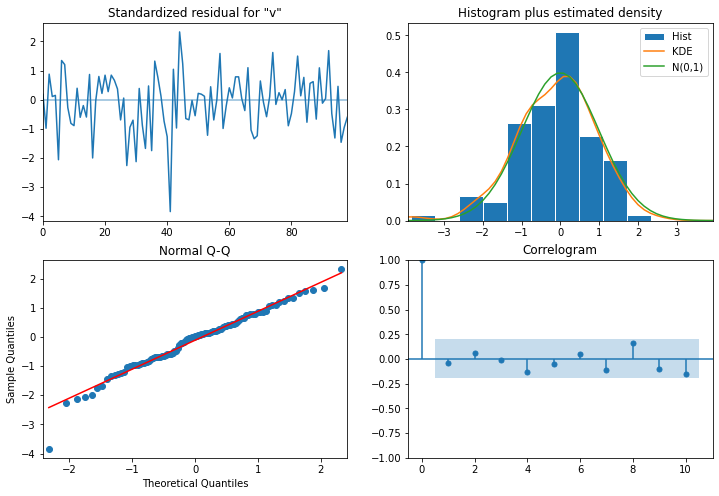

In [23]:
# let the model diffentiate by itself
from statsmodels.tsa.arima.model import ARIMA

model2 = ARIMA(np.log(y).dropna(), order=(1,1,1))
result2 = model2.fit()

print(result2.summary())

# Diagnostics
result2.plot_diagnostics(figsize=(12,8))
plt.show()

In [ ]:
##############################################################

In [38]:
# Example 2. SARIMA with real weather data

import statsmodels.api as sm

data = sm.datasets.co2.load_pandas().data
y = data['co2'].resample('M').mean().interpolate()


/Users/ignasi/opt/anaconda3/lib/python3.7/site-packages/statsmodels/graphics/tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


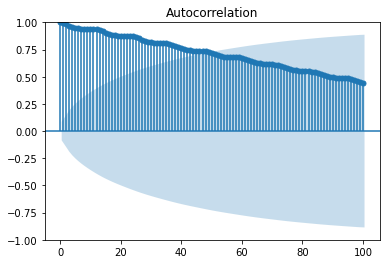

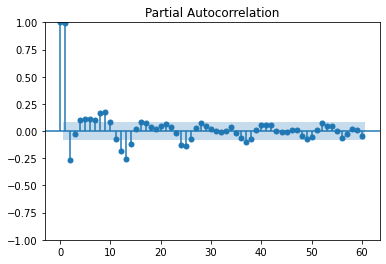

In [39]:
# ACF, PACF
plot_acf(y, lags=100)
plot_pacf(y, lags=60)
plt.show()

In [40]:
# Strong spikes at lag 12, 24 → seasonality

# Slow decaying ACF -  non-stationary

# Apply seasonal differencing!

In [41]:
# Fit SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

result = model.fit()
print(result.summary())

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.09736D-01    |proj g|=  8.43883D-01

At iterate    5    f=  2.64131D-01    |proj g|=  2.65255D-01

At iterate   10    f=  2.38009D-01    |proj g|=  4.48055D-02

At iterate   15    f=  2.37288D-01    |proj g|=  9.02499D-03

At iterate   20    f=  2.37101D-01    |proj g|=  9.94096D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     22     29      1     0     0   7.881D-06   2.371D-01
  F =  0.23710078717942118     

CONVERG

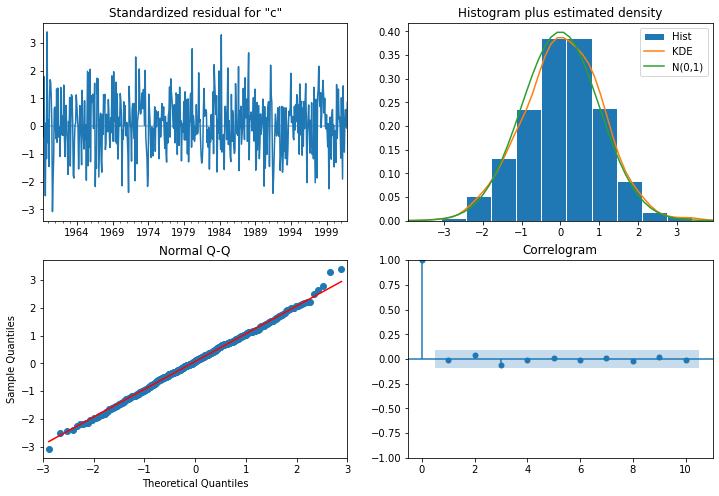

In [42]:
# Diagnostics
result.plot_diagnostics(figsize=(12,8))
plt.show()

In [43]:
# Things to look for:
# Residuals ≈ white noise
# Q-Q plot ≈ normal
# No structure in ACF

In [ ]:
###################################################################

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -286.933
Date:                Fri, 10 Apr 2026   AIC                            581.866
Time:                        10:50:20   BIC                            595.060
Sample:                             0   HQIC                           587.205
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0118      0.044      0.268      0.789      -0.075       0.098
ar.L1          0.3354      0.213      1.576      0.115      -0.082       0.753
ma.L1         -0.5970      0.183     -3.259      0.0

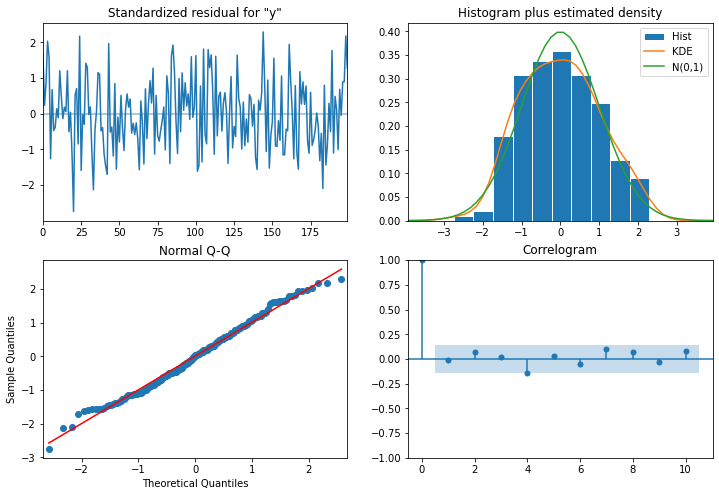

In [61]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def fractional_noise(d, n):

    w = np.random.normal(size=n)
    x = np.zeros(n)
    
    # compute coefficients recursively
    coef = np.zeros(n)
    coef[0] = 1
    
    for k in range(1, n):
        coef[k] = coef[k-1] * (k-1-d) / k
    
    # apply convolution-like sum
    for t in range(n):
        x[t] = np.dot(coef[:t+1], w[t::-1])
    
    return x

np.random.seed(0)
n = 200
d = 0.3

y = fractional_noise(d, n)
y = pd.Series(y)

# We use ARIMA, as FARIMA is not directly supported by statsmodel
model = ARIMA(y, order=(1,0,1))
result = model.fit()

print(result.summary())

# Diagnostics
result.plot_diagnostics(figsize=(12,8))
plt.show()

In [63]:
forecast = result.forecast(steps=10)
print(forecast)

200   -0.556312
201   -0.178737
202   -0.052088
203   -0.009606
204    0.004644
205    0.009423
206    0.011027
207    0.011564
208    0.011745
209    0.011805
Name: predicted_mean, dtype: float64


In [ ]:
# Final diagnostics:

# ARIMA:
# ACF: exponential decay
# PACF: sharp cutoff
# Residuals: white noise
    
# SARIMA:
# ACF: spikes at seasonal lags (e.g., 12, 24)
# After seasonal differencing - cleaner structure

# FARIMA:
# ACF: hyperbolic (slow) decay
# Even large lags remain significant
# Needs fractional differencing
